In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [17]:
from langgraph.graph import START, END, StateGraph
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


In [5]:
llm = ChatGroq(
    model = 'openai/gpt-oss-20b'
)

In [4]:
class MailState(BaseModel):
    query:str = ''
    draft:str = ''
    human_feedback:str = ''
    final_response:str = ''

In [21]:
# defining the node
def DraftEmail(state:MailState)->MailState:
    draft = llm.invoke(state.query).content
    state.draft = draft
    return state

def HumanFeedBack(state:MailState)->MailState:
        feedback = interrupt({
            'draft_email':state.draft,
            'question':'do you want to continue or re-write the mail'
        })
        fb = (feedback or "" ).strip().lower()
        if fb in ('approved','ok','yes'):
            state.human_feedback = ""
            return state
        else:
            state.human_feedback = feedback
            return state    
          
def Finalize_node(state:MailState)->MailState:
    if state.human_feedback:
        state.final_response = state.humaan_feedback
        return state
    else:
        print('email sent successfully')
        state.final_response = 'email sent successfully'
        return state    

In [20]:
# graph creation
graph_builder = StateGraph(MailState)

# nodes

graph_builder.add_node('draft', DraftEmail)
graph_builder.add_node('human_fb', HumanFeedBack)
graph_builder.add_node('final', Finalize_node)

# edge

graph_builder.add_edge(START, 'draft')
graph_builder.add_edge('draft', 'human_fb')
graph_builder.add_edge('human_fb', 'final')
graph_builder.add_edge('final', END)

graph = graph_builder.compile(checkpointer = InMemorySaver())

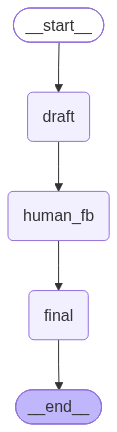

In [13]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [14]:
config = {'configurable':{'thread_id':1}}

In [15]:
res = graph.invoke({
    'query':'i want to send a email for medical leave requeste, dates will be second june to 5th june, so create a simple mail'},
    config = config
)

In [19]:
res

{'query': 'i want to send a email for medical leave requeste, dates will be second june to 5th june, so create a simple mail',
 'draft': '**Subject:** Medical Leave Request – 2\u202fJune\u202f–\u202f5\u202fJune  \n\nDear [Manager’s Name],\n\nI hope you are well. I am writing to request medical leave from **Monday, 2\u202fJune** to **Thursday, 5\u202fJune**. I will keep you updated on my recovery and plan to return to work on Friday, 6\u202fJune.\n\nI have ensured that all urgent tasks are covered and have briefed [Colleague’s Name] on my current projects.\n\nThank you for your understanding.\n\nKind regards,\n\n[Your Name]  \n[Your Position]  \n[Your Contact Information]',
 'human_feedback': '',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request – 2\u202fJune\u202f–\u202f5\u202fJune  \n\nDear [Manager’s Name],\n\nI hope you are well. I am writing to request medical leave from **Monday, 2\u202fJune** to **Thursday, 5\u202fJune**

In [22]:
res = graph.invoke(Command(resume = 'I do not want to send this email'), config = config)

In [23]:
res

{'query': '',
 'draft': 'It looks like your message didn’t come through. Could you let me know what you’d like help with?',
 'human_feedback': '',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': 'It looks like your message didn’t come through. Could you let me know what you’d like help with?', 'question': 'do you want to continue or re-write the mail'}, id='4a115e5308295ece69f274081f5cc042')]}